In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/ai-index-report-2025")

print("Path to dataset files:", path)

100%|██████████| 61.9M/61.9M [00:00<00:00, 119MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/ai-index-report-2025/versions/1


In [ ]:
import os

os.listdir(path)

['hai_ai_index_report_2025.pdf', 'PUBLIC DATA_ 2025 AI Index Report']

In [ ]:
data_folder = os.path.join(path, "PUBLIC DATA_ 2025 AI Index Report")

os.listdir(data_folder)

['5. Science and Medicine',
 '1. Research and Development',
 '2. Technical Performance',
 '3. Responsible AI',
 '6. Policy and Governance',
 '7. Education',
 '4. Economy',
 '8. Public Opinion']

In [ ]:
policy_folder = os.path.join(data_folder, "6. Policy and Governance")

os.listdir(policy_folder)

['Charts', 'Data']

In [ ]:
import os

data_folder = os.path.join(policy_folder, "Data")
os.listdir(data_folder)

['fig_6.3.13.csv',
 'fig_6.2.14.csv',
 'fig_6.3.8.csv',
 'fig_6.3.12.csv',
 'fig_6.2.20.csv',
 'fig_6.2.17.csv',
 'fig_6.2.6.csv',
 'fig_6.2.11.csv',
 'fig_6.2.19.csv',
 'fig_6.3.7.csv',
 'fig_6.2.7.csv',
 'fig_6.3.6.csv',
 'fig_6.3.9.csv',
 'fig_6.3.1.csv',
 'fig_6.3.4.csv',
 'fig_6.2.4.csv',
 'fig_6.2.12.csv',
 'fig_6.2.15.csv',
 'fig_6.2.9.csv',
 'fig_6.2.18.csv',
 'fig_6.3.2.csv',
 'fig_6.2.8.csv',
 'fig_6.3.3.csv',
 'fig_6.2.3.csv',
 'fig_6.2.1.csv',
 'fig_6.2.16.csv',
 'fig_6.2.2.csv',
 'fig_6.3.10.csv',
 'fig_6.2.13.csv',
 'fig_6.3.5.csv']

In [ ]:
import pandas as pd
import os

files = os.listdir(data_folder)

for file in files:
    print("\n========================")
    print("FILE:", file)

    df = pd.read_csv(os.path.join(data_folder, file))

    print("Columns:", df.columns)
    print(df.head())


FILE: fig_6.3.13.csv
Columns: Index(['Public spending on AI-related grants (% of total)', 'Funding agency'], dtype='object')
  Public spending on AI-related grants (% of total)  \
0                                            43.57%   
1                                            27.91%   
2                                            16.06%   
3                                             5.38%   
4                                             2.62%   

                            Funding agency  
0  Department of Health and Human Services  
1              National Science Foundation  
2                                   Others  
3                   Department of Commerce  
4                    Department of Defense  

FILE: fig_6.2.14.csv
Columns: Index(['Year', 'Number of mentions'], dtype='object')
   Year  Number of mentions
0  2016                 204
1  2017                 458
2  2018                 863
3  2019                 826
4  2020                 827

FILE: fig_6.3.8.csv

In [ ]:
laws = pd.read_csv(os.path.join(data_folder, "fig_6.2.1.csv"))
mentions = pd.read_csv(os.path.join(data_folder, "fig_6.2.17.csv"))
contracts_value = pd.read_csv(os.path.join(data_folder, "fig_6.3.1.csv"))
contracts_count = pd.read_csv(os.path.join(data_folder, "fig_6.3.2.csv"))

In [ ]:
laws.head()

,Geographic area,"Number of AI-related bills passed into law, 2016-24"
0,Algeria,0
1,Norway,0
2,Northern Mariana Islands,0
3,New Zealand,0
4,Netherlands,0


In [ ]:
laws[laws["Geographic area"] == "Canada"]

,Geographic area,"Number of AI-related bills passed into law, 2016-24"
82,Canada,1


In [ ]:
mentions.head()

,Geographic area,Number of AI-related bills passed into law,Number of AI mentions
0,United States,24,538
1,Portugal,20,41
2,Russia,20,108
3,Belgium,18,18
4,Spain,12,1200


In [ ]:
mentions[mentions["Geographic area"] == "Canada"]

,Geographic area,Number of AI-related bills passed into law,Number of AI mentions
19,Canada,1,417


In [ ]:
contracts_value.head()


,Country,Tot. Value (M$)
0,United States,5233.099796
1,United Kingdom,568.475448
2,Germany,278.073428
3,France,190.103431
4,Spain,99.712836


In [ ]:
contracts_value[contracts_value["Country"] == "Canada"]

,Country,Tot. Value (M$)


In [ ]:
contracts_count.head()

,Country,N. Contracts
0,United States,2678
1,United Kingdom,555
2,Germany,409
3,France,139
4,Poland,136


In [ ]:
contracts_count[contracts_count["Country"] == "Canada"]

,Country,N. Contracts


## Indicator Selection

The Policy and Governance pillar uses indicators intended to capture:
- regulatory activity,
- legislative attention to AI,
- public-sector AI procurement,
- national AI strategy strength,
- and the broader operating environment for AI.

These indicators were selected because they reflect both policy activity and governance capacity.

In [ ]:
# Rename columns for consistency
laws = laws.rename(columns={
    "Geographic area": "Country",
    "Number of AI-related bills passed into law, 2016-24": "AI_Bills_2016_24"
})

mentions = mentions.rename(columns={
    "Geographic area": "Country",
    "Number of AI-related bills passed into law": "AI_Bills_Recent",
    "Number of AI mentions": "AI_Mentions"
})

contracts_value = contracts_value.rename(columns={
    "Tot. Value (M$)": "AI_Contract_Value_M"
})

contracts_count = contracts_count.rename(columns={
    "N. Contracts": "AI_Contracts_Count"
})

# Keep only needed columns
laws = laws[["Country", "AI_Bills_2016_24"]]
mentions = mentions[["Country", "AI_Bills_Recent", "AI_Mentions"]]
contracts_value = contracts_value[["Country", "AI_Contract_Value_M"]]
contracts_count = contracts_count[["Country", "AI_Contracts_Count"]]

# Merge all datasets
policy_df = laws.merge(mentions, on="Country", how="outer")
policy_df = policy_df.merge(contracts_value, on="Country", how="outer")
policy_df = policy_df.merge(contracts_count, on="Country", how="outer")

# Preview
policy_df.head()

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count
0,Algeria,0.0,NaN,NaN,NaN,NaN
1,Andorra,3.0,3.0,1.0,NaN,NaN
2,Antigua and Barbuda,0.0,NaN,NaN,NaN,NaN
3,Argentina,3.0,NaN,NaN,NaN,NaN
4,Armenia,0.0,NaN,NaN,NaN,NaN


In [ ]:
policy_df

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count
0,Algeria,0.0,NaN,NaN,NaN,NaN
1,Andorra,3.0,3.0,1.0,NaN,NaN
2,Antigua and Barbuda,0.0,NaN,NaN,NaN,NaN
3,Argentina,3.0,NaN,NaN,NaN,NaN
4,Armenia,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
114,Uruguay,0.0,NaN,NaN,NaN,NaN
115,Vietnam,0.0,NaN,NaN,NaN,NaN
116,Yemen,0.0,NaN,NaN,NaN,NaN
117,Zambia,0.0,NaN,NaN,NaN,NaN


## Methodology

The Policy and Governance pillar was constructed using seven indicators:
- AI-related bills passed into law (2016–2024),
- recent AI-related bills,
- mentions of AI in legislative proceedings,
- public AI contract value,
- number of public AI contracts,
- Government Strategy,
- Operating Environment.

Missing values were filled with 0. All indicators were normalized using MinMax scaling, and the final Policy_Governance_Score was calculated as the average of the normalized indicators.

In [ ]:
policy_df[policy_df["Country"] == "Canada"]

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count
22,Canada,1.0,1.0,417.0,NaN,NaN


In [ ]:
import kagglehub
import os
import pandas as pd

ai_index_path = kagglehub.dataset_download("katerynameleshenko/ai-index")
print("Dataset path:", ai_index_path)
print("Files:", os.listdir(ai_index_path))

100%|██████████| 2.38k/2.38k [00:00<00:00, 3.10MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/katerynameleshenko/ai-index/versions/1
Files: ['AI_index_db.csv']


In [ ]:
csv_files = [f for f in os.listdir(ai_index_path) if f.lower().endswith(".csv")]
print(csv_files)

['AI_index_db.csv']


In [ ]:
ai_index_df = pd.read_csv(os.path.join(ai_index_path, "AI_index_db.csv"))
ai_index_df.head()

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


In [ ]:
gov_extra = ai_index_df[["Country", "Government Strategy", "Operating Environment"]].copy()

gov_extra.head()

,Country,Government Strategy,Operating Environment
0,United States of America,77.39,64.56
1,China,94.87,91.57
2,United Kingdom,82.82,74.65
3,Canada,100.00,93.94
4,Israel,43.91,82.44


In [ ]:
gov_extra[gov_extra["Country"] == "Canada"]

,Country,Government Strategy,Operating Environment
3,Canada,100.0,93.94


In [ ]:
gov_extra["Country"] = gov_extra["Country"].replace({
    "United States of America": "United States"
})

In [ ]:
gov_extra["Country"] = gov_extra["Country"].str.strip()
policy_df["Country"] = policy_df["Country"].str.strip()

In [ ]:
policy_df = policy_df.merge(gov_extra, on="Country", how="left")

policy_df

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment
0,Algeria,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Andorra,3.0,3.0,1.0,NaN,NaN,NaN,NaN
2,Antigua and Barbuda,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,3.0,NaN,NaN,NaN,NaN,54.94,75.95
4,Armenia,0.0,NaN,NaN,NaN,NaN,14.40,58.40
...,...,...,...,...,...,...,...,...
114,Uruguay,0.0,NaN,NaN,NaN,NaN,30.92,70.75
115,Vietnam,0.0,NaN,NaN,NaN,NaN,68.86,37.61
116,Yemen,0.0,NaN,NaN,NaN,NaN,NaN,NaN
117,Zambia,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
policy_df[policy_df["Country"] == "Canada"]

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment
22,Canada,1.0,1.0,417.0,NaN,NaN,100.0,93.94


Policy and Governance indicators were selected to capture three key dimensions of national AI governance: regulatory activity (AI-related laws and legislative mentions), government investment (AI-related procurement contracts), and strategic governance capacity (Government Strategy and Operating Environment indicators from the AI Index database). These indicators collectively measure how actively governments regulate, invest in, and strategically support AI development.

In [ ]:
policy_cols = [
    "AI_Bills_2016_24",
    "AI_Bills_Recent",
    "AI_Mentions",
    "AI_Contract_Value_M",
    "AI_Contracts_Count",
    "Government Strategy",
    "Operating Environment"
]

policy_df[policy_cols] = policy_df[policy_cols].fillna(0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

policy_df[policy_cols] = scaler.fit_transform(policy_df[policy_cols])

In [ ]:
policy_df["Policy_Governance_Score"] = policy_df[policy_cols].mean(axis=1)

In [ ]:
policy_df.sort_values("Policy_Governance_Score", ascending=False).head(15)

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment,Policy_Governance_Score
113,United States,1.000000,1.000000,0.448333,1.000000,1.000000,0.7739,0.6456,0.838262
97,Spain,0.407407,0.500000,1.000000,0.019054,0.045183,0.9128,0.7536,0.519721
112,United Kingdom,0.370370,0.416667,0.591667,0.108631,0.207244,0.8282,0.7465,0.467040
83,Portugal,0.740741,0.833333,0.034167,0.002218,0.005601,0.7069,0.8066,0.447080
85,Russia,0.740741,0.833333,0.090000,0.000000,0.000000,0.9040,0.5285,0.442368
35,France,0.333333,0.375000,0.249167,0.036327,0.051904,0.9120,0.8002,0.393990
13,Belgium,0.666667,0.750000,0.015000,0.015964,0.010829,0.6358,0.6408,0.390723
52,Italy,0.370370,0.416667,0.287500,0.008464,0.014190,0.6143,0.8325,0.363427
22,Canada,0.037037,0.041667,0.347500,0.000000,0.000000,1.0000,0.9394,0.337943
24,China,0.148148,0.166667,0.005000,0.000000,0.000000,0.9487,0.9157,0.312031


In [ ]:
policy_df[policy_df["Country"] == "Canada"]

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment,Policy_Governance_Score
22,Canada,0.037037,0.041667,0.3475,0.0,0.0,1.0,0.9394,0.337943


The Policy and Governance pillar was constructed using seven indicators: AI-related bills passed into law (2016–2024), recent AI-related bills, legislative mentions of AI, public AI contract value, number of AI contracts, Government Strategy, and Operating Environment. Missing values were filled with 0, variables were normalized using MinMax scaling, and the final Policy_Governance_Score was computed as the average of the normalized indicators.

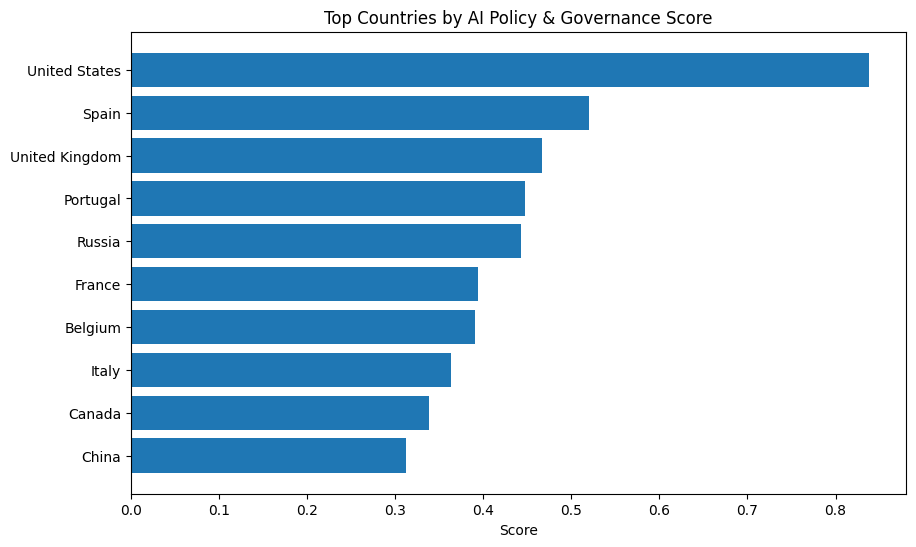

In [ ]:
import matplotlib.pyplot as plt

top10 = policy_df.sort_values("Policy_Governance_Score", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Country"], top10["Policy_Governance_Score"])
plt.gca().invert_yaxis()
plt.title("Top Countries by AI Policy & Governance Score")
plt.xlabel("Score")
plt.show()

In [ ]:
policy_df[policy_df["Country"] == "Canada"]

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment,Policy_Governance_Score
22,Canada,0.037037,0.041667,0.3475,0.0,0.0,1.0,0.9394,0.337943


In [ ]:
policy_cols = [
    "AI_Bills_2016_24",
    "AI_Bills_Recent",
    "AI_Mentions",
    "AI_Contract_Value_M",
    "AI_Contracts_Count",
    "Government Strategy",
    "Operating Environment"
]

policy_df[policy_cols].corr()

,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment
AI_Bills_2016_24,1.000000,0.917418,0.461664,0.562954,0.575347,0.400444,0.275925
AI_Bills_Recent,0.917418,1.000000,0.496279,0.531042,0.546979,0.433155,0.296778
AI_Mentions,0.461664,0.496279,1.000000,0.329134,0.371759,0.435533,0.315402
AI_Contract_Value_M,0.562954,0.531042,0.329134,1.000000,0.989472,0.180647,0.118789
AI_Contracts_Count,0.575347,0.546979,0.371759,0.989472,1.000000,0.221451,0.150758
Government Strategy,0.400444,0.433155,0.435533,0.180647,0.221451,1.000000,0.886560
Operating Environment,0.275925,0.296778,0.315402,0.118789,0.150758,0.886560,1.000000


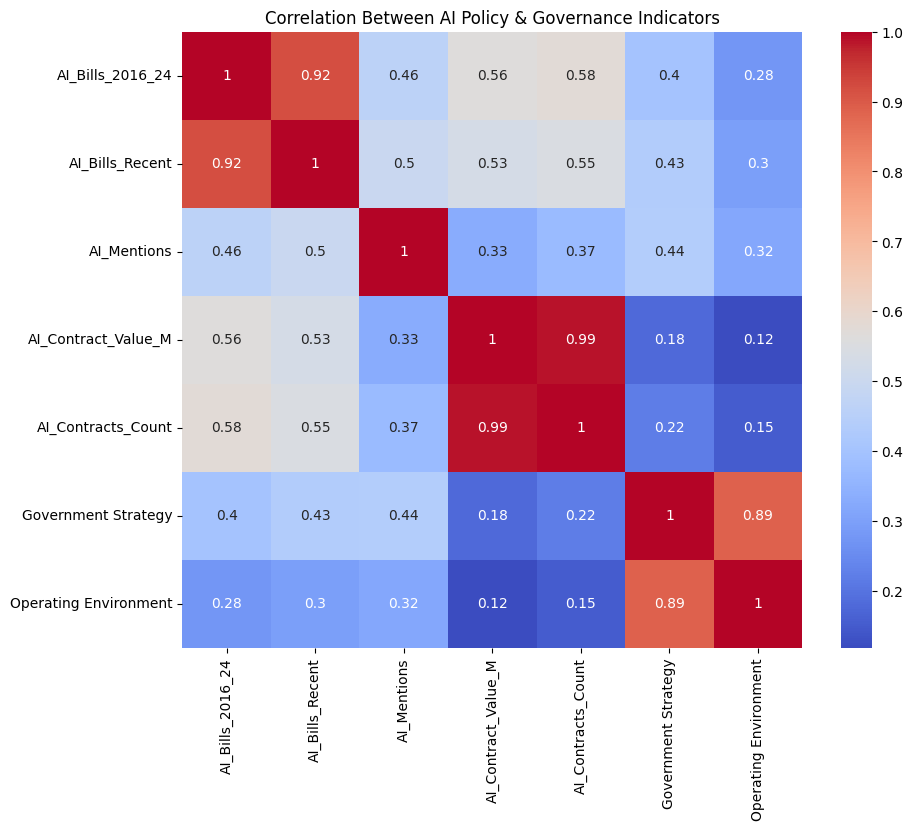

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    policy_df[policy_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between AI Policy & Governance Indicators")
plt.show()

The correlation analysis above shows that Government Strategy and Operating Environment are strongly associated with higher levels of AI policy activity. Countries with stronger national AI strategies tend to exhibit more legislative engagement and public investment in AI.

In [ ]:
top_countries = ["United States", "China", "United Kingdom", "Canada"]

policy_df[policy_df["Country"].isin(top_countries)]

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment,Policy_Governance_Score
22,Canada,0.037037,0.041667,0.347500,0.000000,0.000000,1.0000,0.9394,0.337943
24,China,0.148148,0.166667,0.005000,0.000000,0.000000,0.9487,0.9157,0.312031
112,United Kingdom,0.370370,0.416667,0.591667,0.108631,0.207244,0.8282,0.7465,0.467040
113,United States,1.000000,1.000000,0.448333,1.000000,1.000000,0.7739,0.6456,0.838262


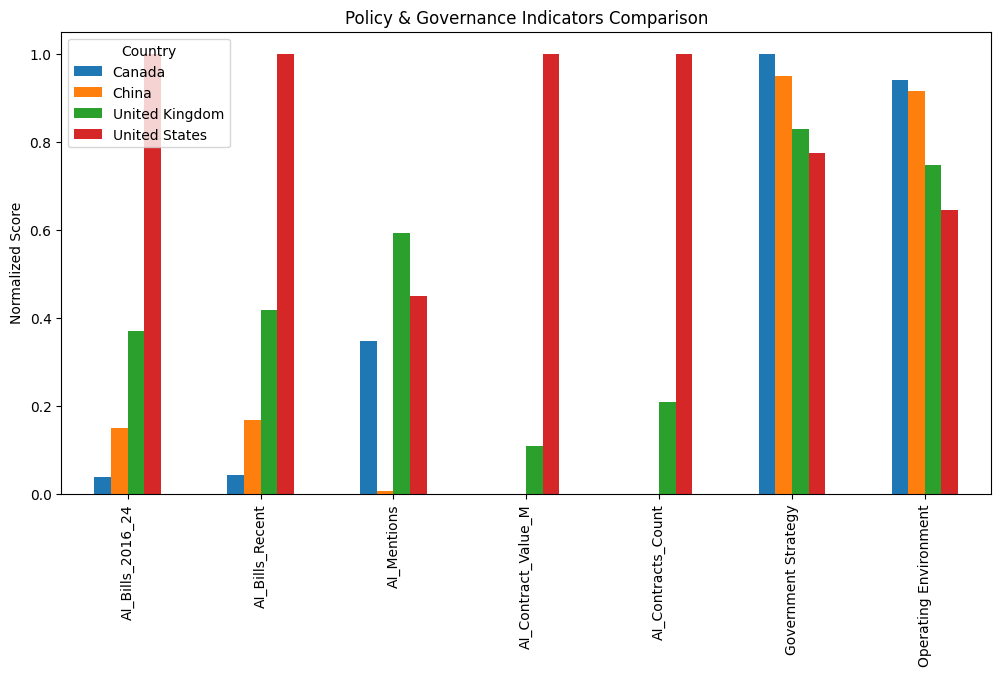

In [ ]:
subset = policy_df[policy_df["Country"].isin(top_countries)]

subset = subset.set_index("Country")

subset[policy_cols].T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Policy & Governance Indicators Comparison")
plt.ylabel("Normalized Score")
plt.show()

Canada performs strongly in Government Strategy and Operating Environment, reflecting strong national policy commitment and a supportive institutional environment. However, Canada appears weaker in the public AI contracts variables, likely due to limited coverage in the source dataset rather than necessarily lower real-world activity. Overall, Canada’s policy and governance performance appears solid but not at the level of the top-ranked countries such as the United States and United Kingdom.

In [ ]:
final_policy_table = policy_df[[
    "Country",
    "AI_Bills_2016_24",
    "AI_Bills_Recent",
    "AI_Mentions",
    "AI_Contract_Value_M",
    "AI_Contracts_Count",
    "Government Strategy",
    "Operating Environment",
    "Policy_Governance_Score"
]].sort_values("Policy_Governance_Score", ascending=False)

final_policy_table.head(15)

,Country,AI_Bills_2016_24,AI_Bills_Recent,AI_Mentions,AI_Contract_Value_M,AI_Contracts_Count,Government Strategy,Operating Environment,Policy_Governance_Score
113,United States,1.000000,1.000000,0.448333,1.000000,1.000000,0.7739,0.6456,0.838262
97,Spain,0.407407,0.500000,1.000000,0.019054,0.045183,0.9128,0.7536,0.519721
112,United Kingdom,0.370370,0.416667,0.591667,0.108631,0.207244,0.8282,0.7465,0.467040
83,Portugal,0.740741,0.833333,0.034167,0.002218,0.005601,0.7069,0.8066,0.447080
85,Russia,0.740741,0.833333,0.090000,0.000000,0.000000,0.9040,0.5285,0.442368
35,France,0.333333,0.375000,0.249167,0.036327,0.051904,0.9120,0.8002,0.393990
13,Belgium,0.666667,0.750000,0.015000,0.015964,0.010829,0.6358,0.6408,0.390723
52,Italy,0.370370,0.416667,0.287500,0.008464,0.014190,0.6143,0.8325,0.363427
22,Canada,0.037037,0.041667,0.347500,0.000000,0.000000,1.0000,0.9394,0.337943
24,China,0.148148,0.166667,0.005000,0.000000,0.000000,0.9487,0.9157,0.312031


## Interpretation of Results

The results indicate that countries with stronger government strategy and operating environments tend to score higher overall in the Policy and Governance pillar. Canada performs strongly on Government Strategy and Operating Environment, which suggests that it has a supportive institutional setting for AI development. However, Canada appears weaker in the public AI contract indicators, which may partly reflect uneven data coverage across countries. Overall, Canada shows solid performance in this pillar, but remains behind the strongest policy leaders.

## Limitations

Some indicators, especially public AI contract variables, have incomplete country coverage. Missing values were imputed as 0 for consistency in score construction, which may understate performance for countries with limited reporting rather than limited real-world activity.

### Spider Chart Top 10 countries

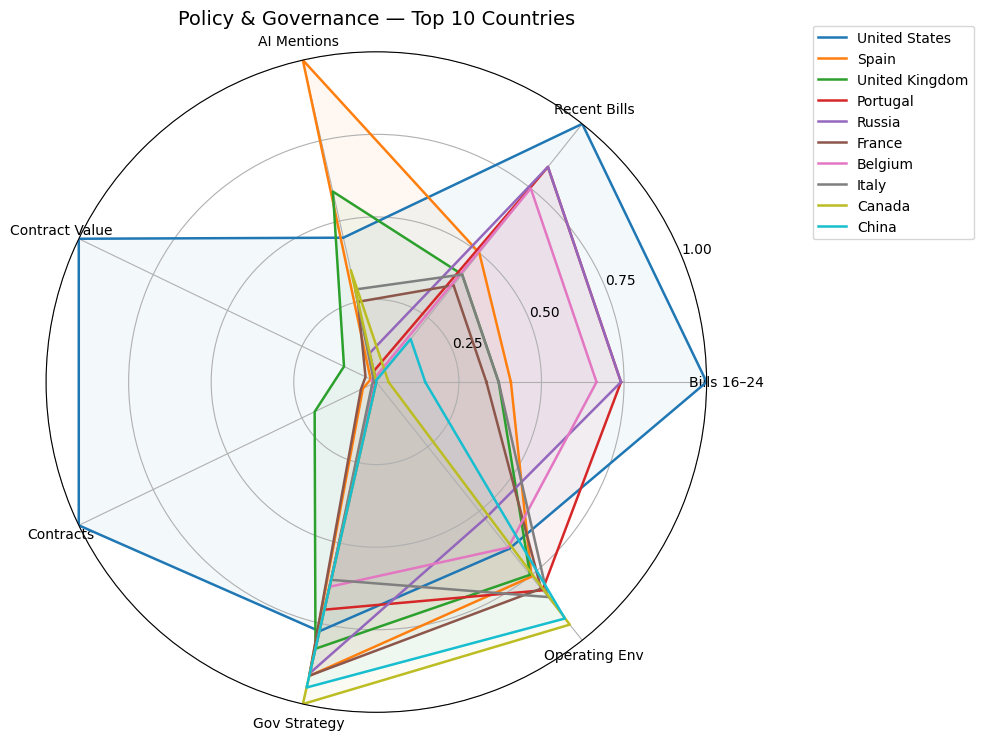

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Get top 10 countries ---
top10 = policy_df.sort_values("Policy_Governance_Score", ascending=False).head(10)
top10_countries = top10["Country"].tolist()

radar_df = policy_df[policy_df["Country"].isin(top10_countries)].copy()
radar_df = radar_df.set_index("Country").loc[top10_countries]

# --- Step 2: Columns ---
policy_cols = [
    "AI_Bills_2016_24",
    "AI_Bills_Recent",
    "AI_Mentions",
    "AI_Contract_Value_M",
    "AI_Contracts_Count",
    "Government Strategy",
    "Operating Environment"
]

# --- Step 3: Clean labels ---
labels = [
    "Bills 16–24",
    "Recent Bills",
    "AI Mentions",
    "Contract Value",
    "Contracts",
    "Gov Strategy",
    "Operating Env"
]

# --- Step 4: Angles ---
num_vars = len(policy_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(polar=True))

for country in radar_df.index:
    values = radar_df.loc[country, policy_cols].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=1.8, label=country)
    ax.fill(angles, values, alpha=0.05)

# --- Step 6: Formatting ---
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"])

plt.title("Policy & Governance — Top 10 Countries", size=14, pad=20)
plt.legend(loc="upper left", bbox_to_anchor=(1.15, 1.05))

plt.tight_layout()
plt.show()

### Canada vs 4 countries

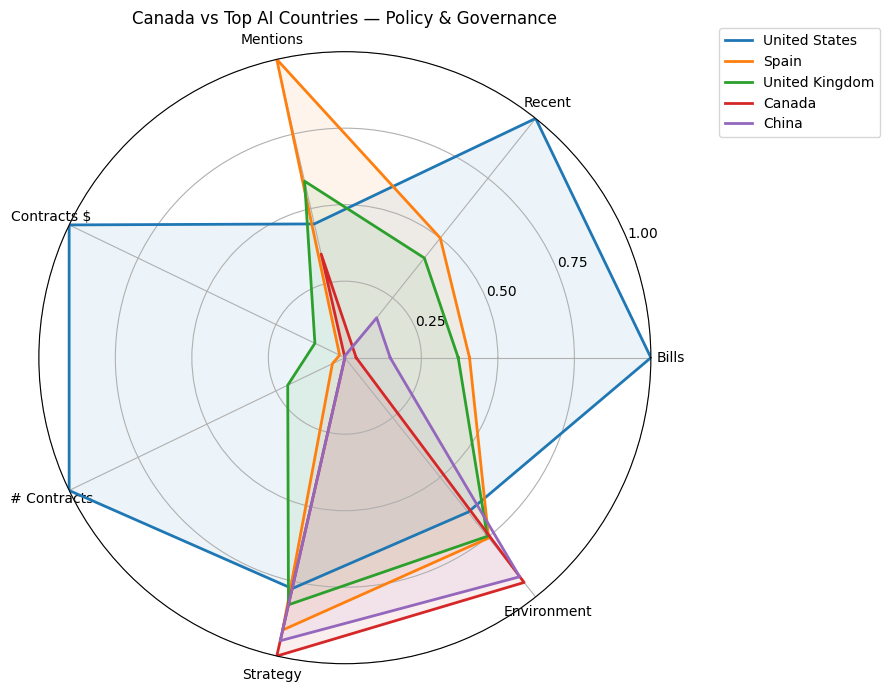

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Countries for comparison ---
compare = ["United States", "Spain", "United Kingdom", "Canada", "China"]

radar_df = policy_df[policy_df["Country"].isin(compare)].copy()
radar_df = radar_df.set_index("Country").loc[compare]

policy_cols = [
    "AI_Bills_2016_24",
    "AI_Bills_Recent",
    "AI_Mentions",
    "AI_Contract_Value_M",
    "AI_Contracts_Count",
    "Government Strategy",
    "Operating Environment"
]

labels = [
    "Bills",
    "Recent",
    "Mentions",
    "Contracts $",
    "# Contracts",
    "Strategy",
    "Environment"
]

num_vars = len(policy_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

for country in radar_df.index:
    values = radar_df.loc[country, policy_cols].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=country)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])

plt.title("Canada vs Top AI Countries — Policy & Governance", pad=20)
plt.legend(loc="upper left", bbox_to_anchor=(1.1, 1.05))

plt.tight_layout()
plt.show()

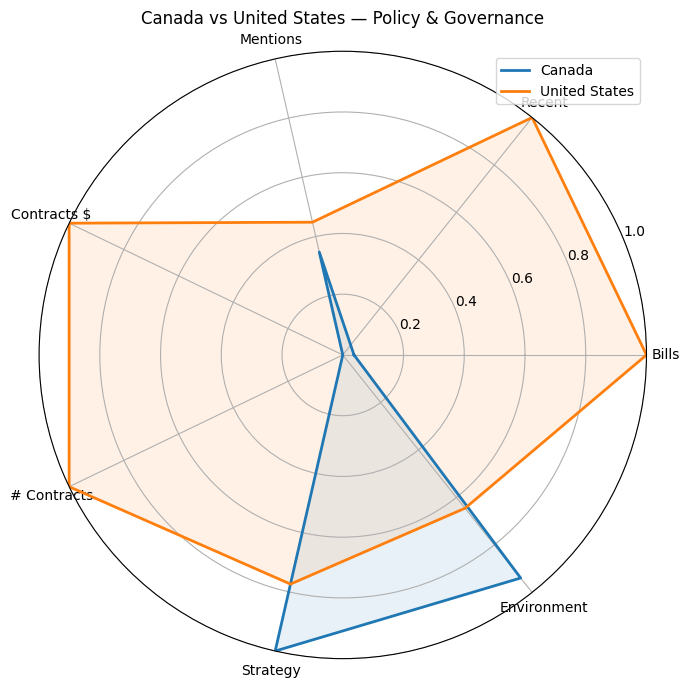

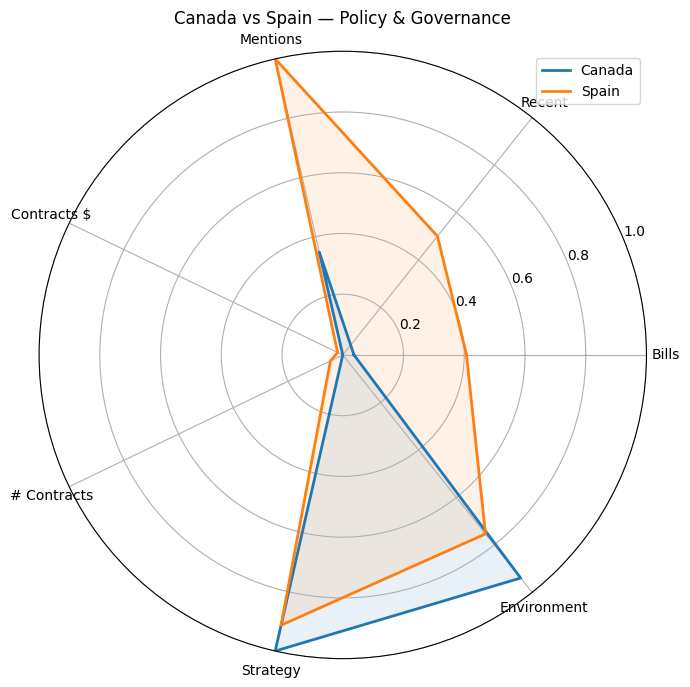

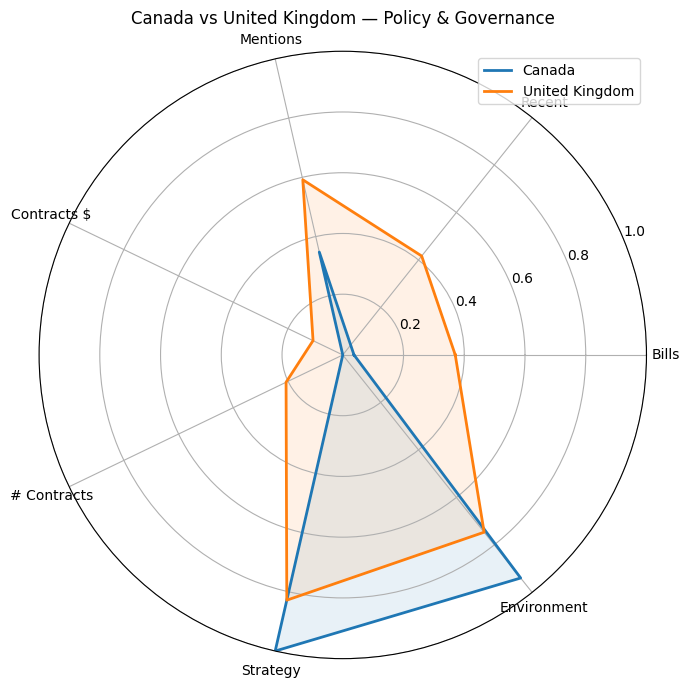

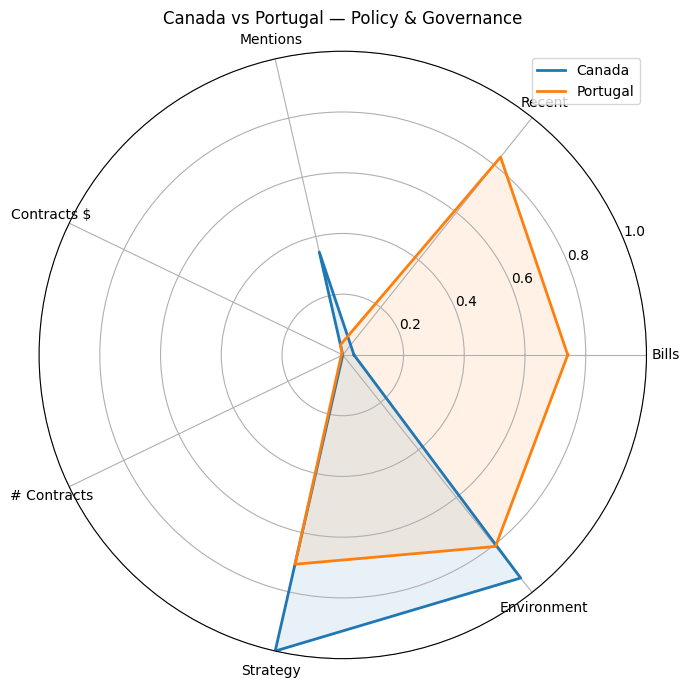

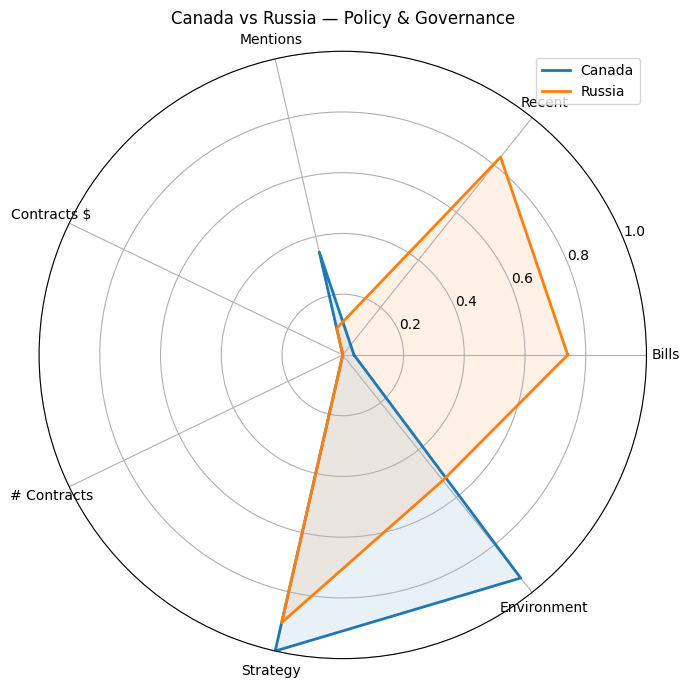

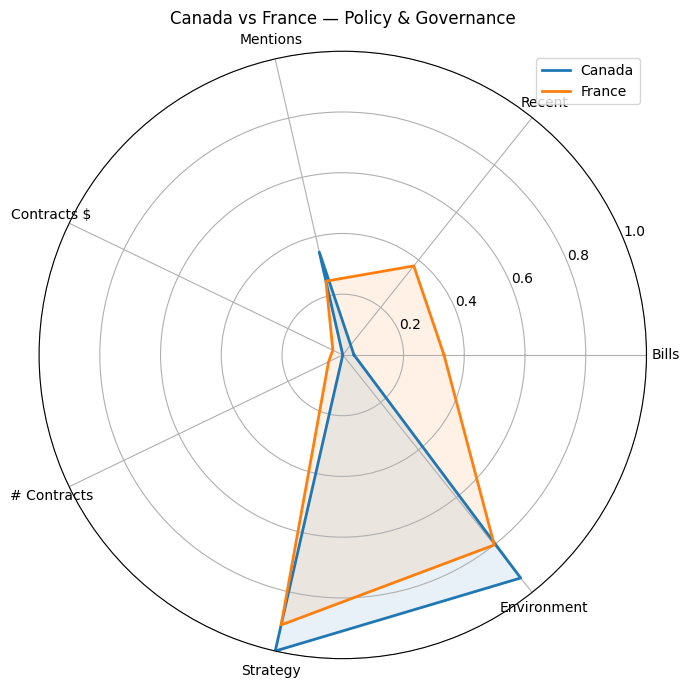

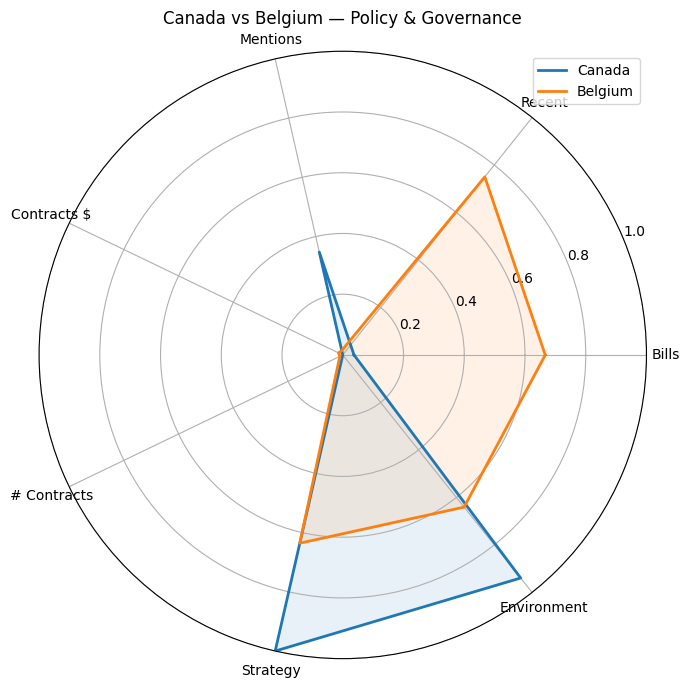

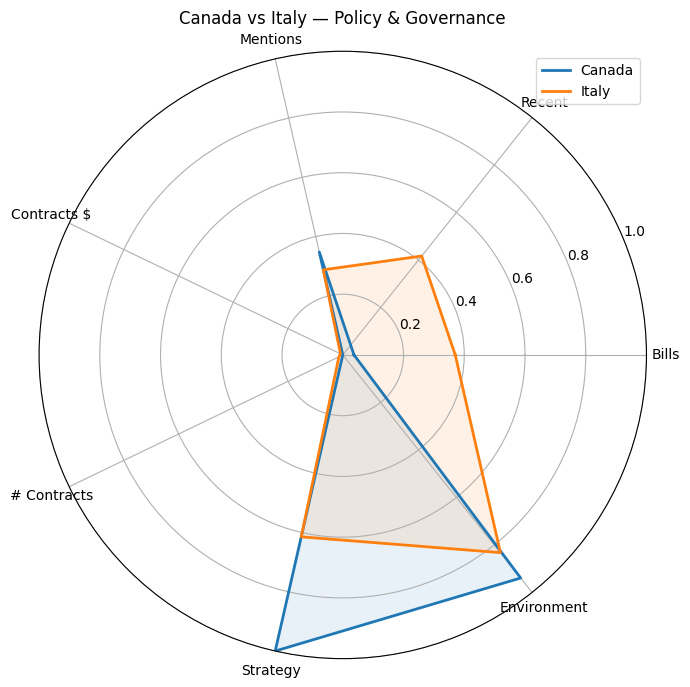

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Sort ranking ---
ranking = policy_df.sort_values("Policy_Governance_Score", ascending=False)

# --- Step 2: Find Canada index ---
canada_index = ranking[ranking["Country"] == "Canada"].index[0]

# --- Step 3: Countries above Canada ---
countries_above = [
    "United States",
    "Spain",
    "United Kingdom",
    "Portugal",
    "Russia",
    "France",
    "Belgium",
    "Italy"
]

# --- Step 4: Columns ---
policy_cols = [
    "AI_Bills_2016_24",
    "AI_Bills_Recent",
    "AI_Mentions",
    "AI_Contract_Value_M",
    "AI_Contracts_Count",
    "Government Strategy",
    "Operating Environment"
]

# --- Step 5: Labels ---
labels = [
    "Bills",
    "Recent",
    "Mentions",
    "Contracts $",
    "# Contracts",
    "Strategy",
    "Environment"
]

# --- Step 6: Function ---
def plot_canada_vs(country):
    compare = ["Canada", country]

    df = policy_df[policy_df["Country"].isin(compare)].copy()
    df = df.set_index("Country")

    num_vars = len(policy_cols)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    for c in compare:
        row = df.loc[c]

        # ensure it's a 1D array
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        values = row[policy_cols].values.flatten().tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2, label=c)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    ax.set_ylim(0, 1)

    plt.title(f"Canada vs {country} — Policy & Governance", pad=20)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# --- Step 7: Generate all charts ---
for country in countries_above:
    plot_canada_vs(country)